# Decision Tree from Scratch: Implementation and Evaluation

В этом проекте реализуется алгоритм решающего дерева с нуля (Gini impurity),
а также проводится сравнение с реализацией sklearn.

## Задача

Цель — реализовать Decision Tree с нуля и сравнить его качество с библиотечной реализацией.

Ключевые шаги:
- реализация критерия Gini
- построение дерева
- обучение и предсказание
- сравнение с sklearn

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, make_classification
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Анализ поведения Decision Tree на синтетических датасетах

Для первичного анализа было решено проверить, как решающее дерево ведёт себя на простых двумерных задачах классификации. Для этого используются три синтетических датасета с разной геометрией классов: `make_circles`, `make_moons` и `make_classification`.

Цель этого этапа — визуализировать разделяющие поверхности дерева, сравнить качество на обучающей и тестовой выборках и понять, насколько модель склонна к переобучению уже при параметрах по умолчанию.

In [16]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = {
    "Circles": make_circles(noise=0.2, factor=0.5, random_state=42),
    "Moons": make_moons(noise=0.2, random_state=42),
    "Classification": make_classification(
        n_classes=3,
        n_clusters_per_class=1,
        n_features=2,
        n_redundant=0,
        class_sep=0.8,
        random_state=3
    )
}

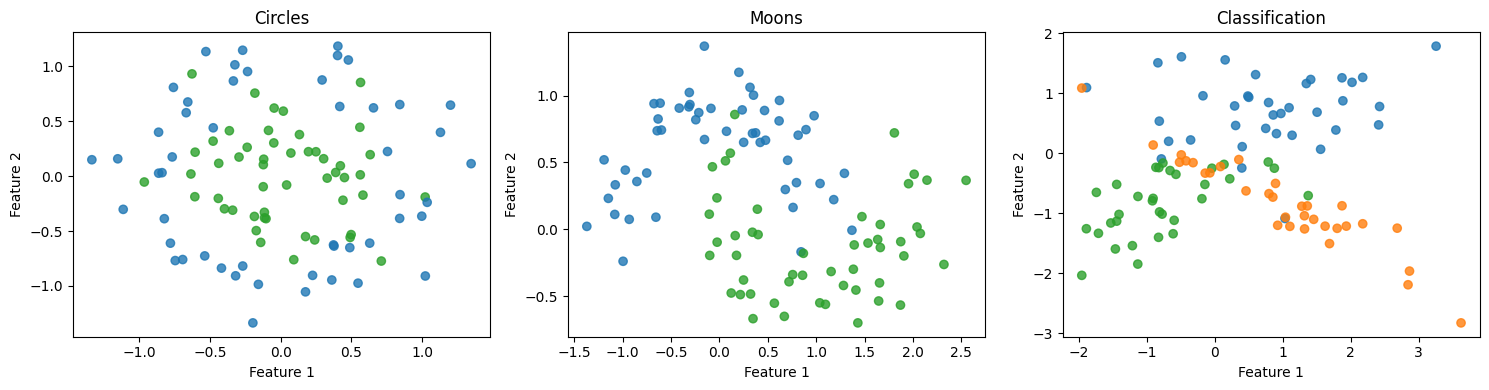

In [17]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

plt.figure(figsize=(15, 4))

for i, (name, (X, y)) in enumerate(datasets.items(), start=1):
    plt.subplot(1, 3, i)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=0.8)
    plt.title(name)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Эксперимент 1. Дерево решений с параметрами по умолчанию

На первом этапе обучается `DecisionTreeClassifier` с параметрами по умолчанию для каждого из трёх датасетов. Далее сравниваются:

- разделяющая поверхность на обучающей и тестовой выборках,
- accuracy на train и test,
- степень переобучения модели.

Такой эксперимент позволяет наглядно увидеть, насколько гибкость дерева помогает описывать сложную геометрию классов и где эта гибкость начинает ухудшать обобщающую способность.

In [18]:
def plot_surface(model, X, y):
    """
    Визуализация разделяющей поверхности классификатора
    на двумерных данных.
    """
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)
    plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap=cmap,
        alpha=0.7,
        edgecolors=np.array(palette)[y],
        linewidths=1.5
    )

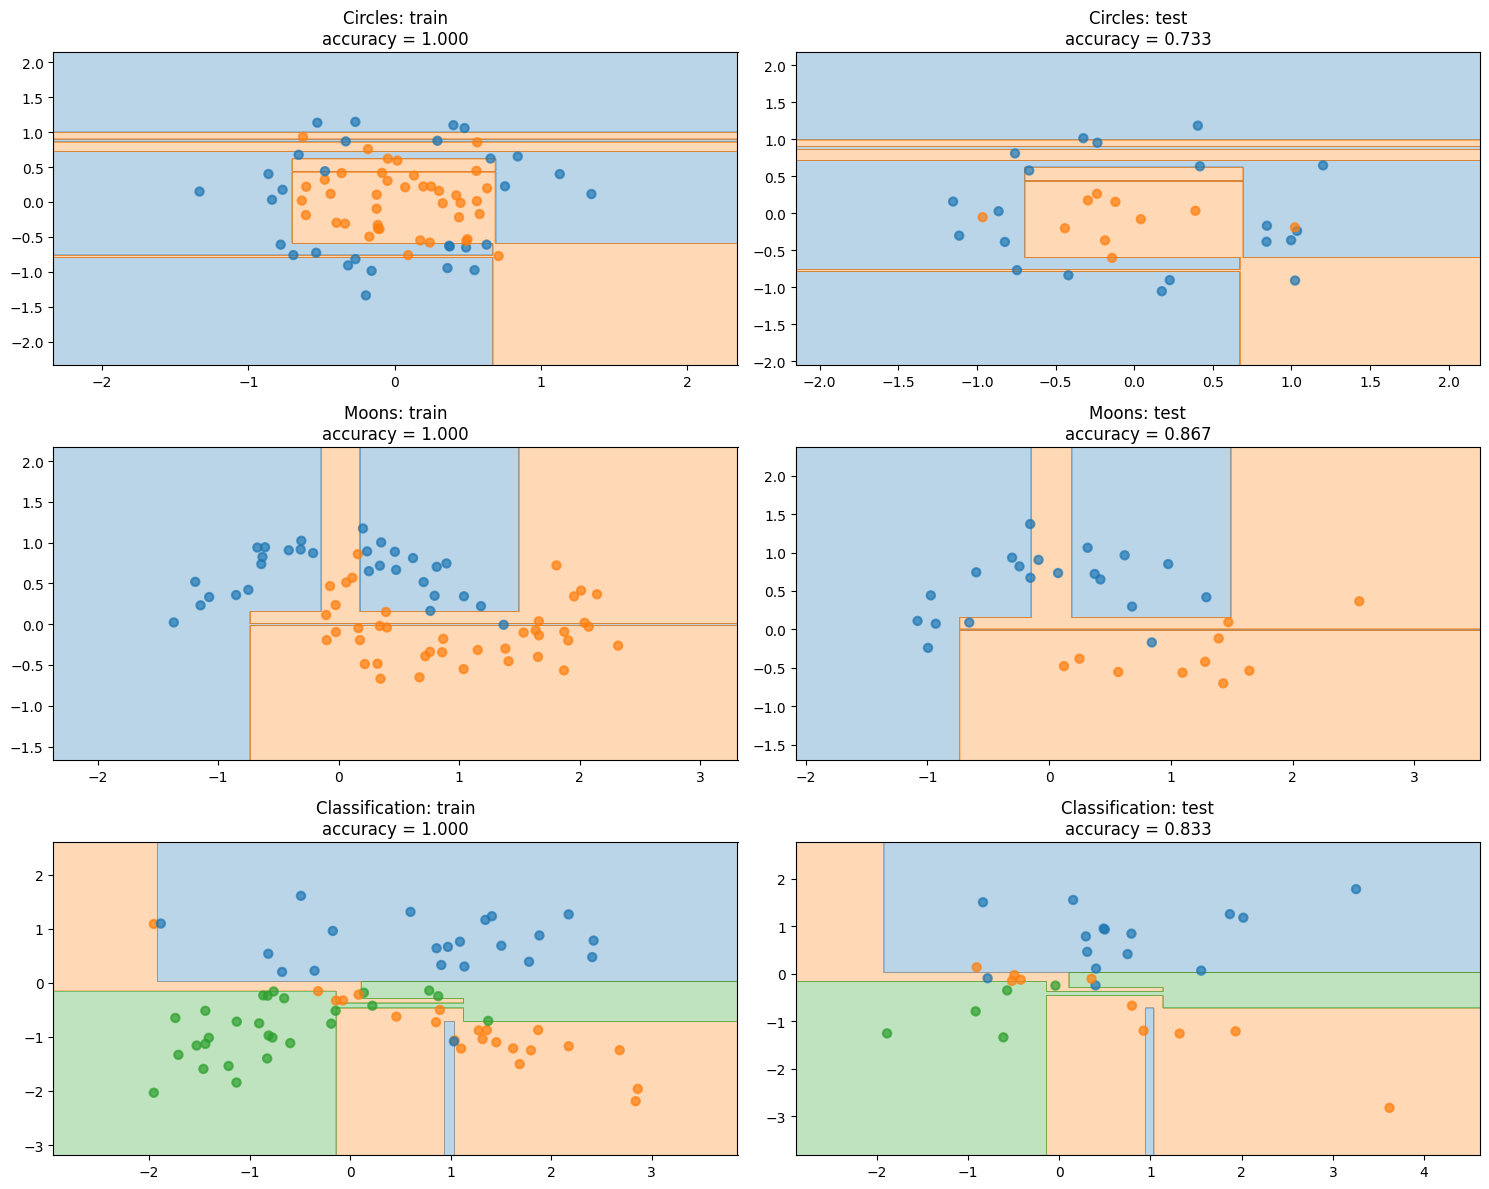

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

results = []

plt.figure(figsize=(15, 12))

for i, (name, (X, y)) in enumerate(datasets.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    results.append({
        "dataset": name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "gap": train_accuracy - test_accuracy
    })

    ax = plt.subplot(3, 2, 2 * i + 1)
    plt.sca(ax)
    plot_surface(clf, X_train, y_train)
    plt.title(f"{name}: train\naccuracy = {train_accuracy:.3f}")

    ax = plt.subplot(3, 2, 2 * i + 2)
    plt.sca(ax)
    plot_surface(clf, X_test, y_test)
    plt.title(f"{name}: test\naccuracy = {test_accuracy:.3f}")

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,dataset,train_accuracy,test_accuracy,gap
0,Circles,1.0,0.733333,0.266667
1,Moons,1.0,0.866667,0.133333
2,Classification,1.0,0.833333,0.166667


## Выводы по эксперименту

Во всех трёх задачах дерево решений показывает более высокое качество на обучающей выборке, чем на тестовой, что указывает на склонность модели к переобучению даже при параметрах по умолчанию.

Наиболее наглядно это проявляется на датасетах с нелинейной структурой классов (`make_circles` и `make_moons`): дерево строит достаточно сложные границы, хорошо подстраиваясь под обучающие точки, но часть этой структуры не переносится на тестовые данные. На более простом синтетическом датасете разрыв между train и test оказывается менее выраженным.

Таким образом, уже на базовом уровне видно, что высокая гибкость дерева одновременно является и его преимуществом, и источником переобучения. Это делает особенно важным дальнейший анализ влияния гиперпараметров, ограничивающих сложность модели.

## Эксперимент 2. Влияние регуляризации дерева на качество модели

После анализа дерева с параметрами по умолчанию следующий шаг — проверить, как ограничения на сложность модели влияют на разделяющую поверхность и качество обобщения.

В этом эксперименте варьируются два ключевых гиперпараметра:
- `max_depth` — ограничение глубины дерева;
- `min_samples_leaf` — минимальное число объектов в листе.

Для каждого набора параметров сравниваются:
- accuracy на обучающей и тестовой выборках,
- форма разделяющей поверхности,
- степень переобучения на разных типах данных.

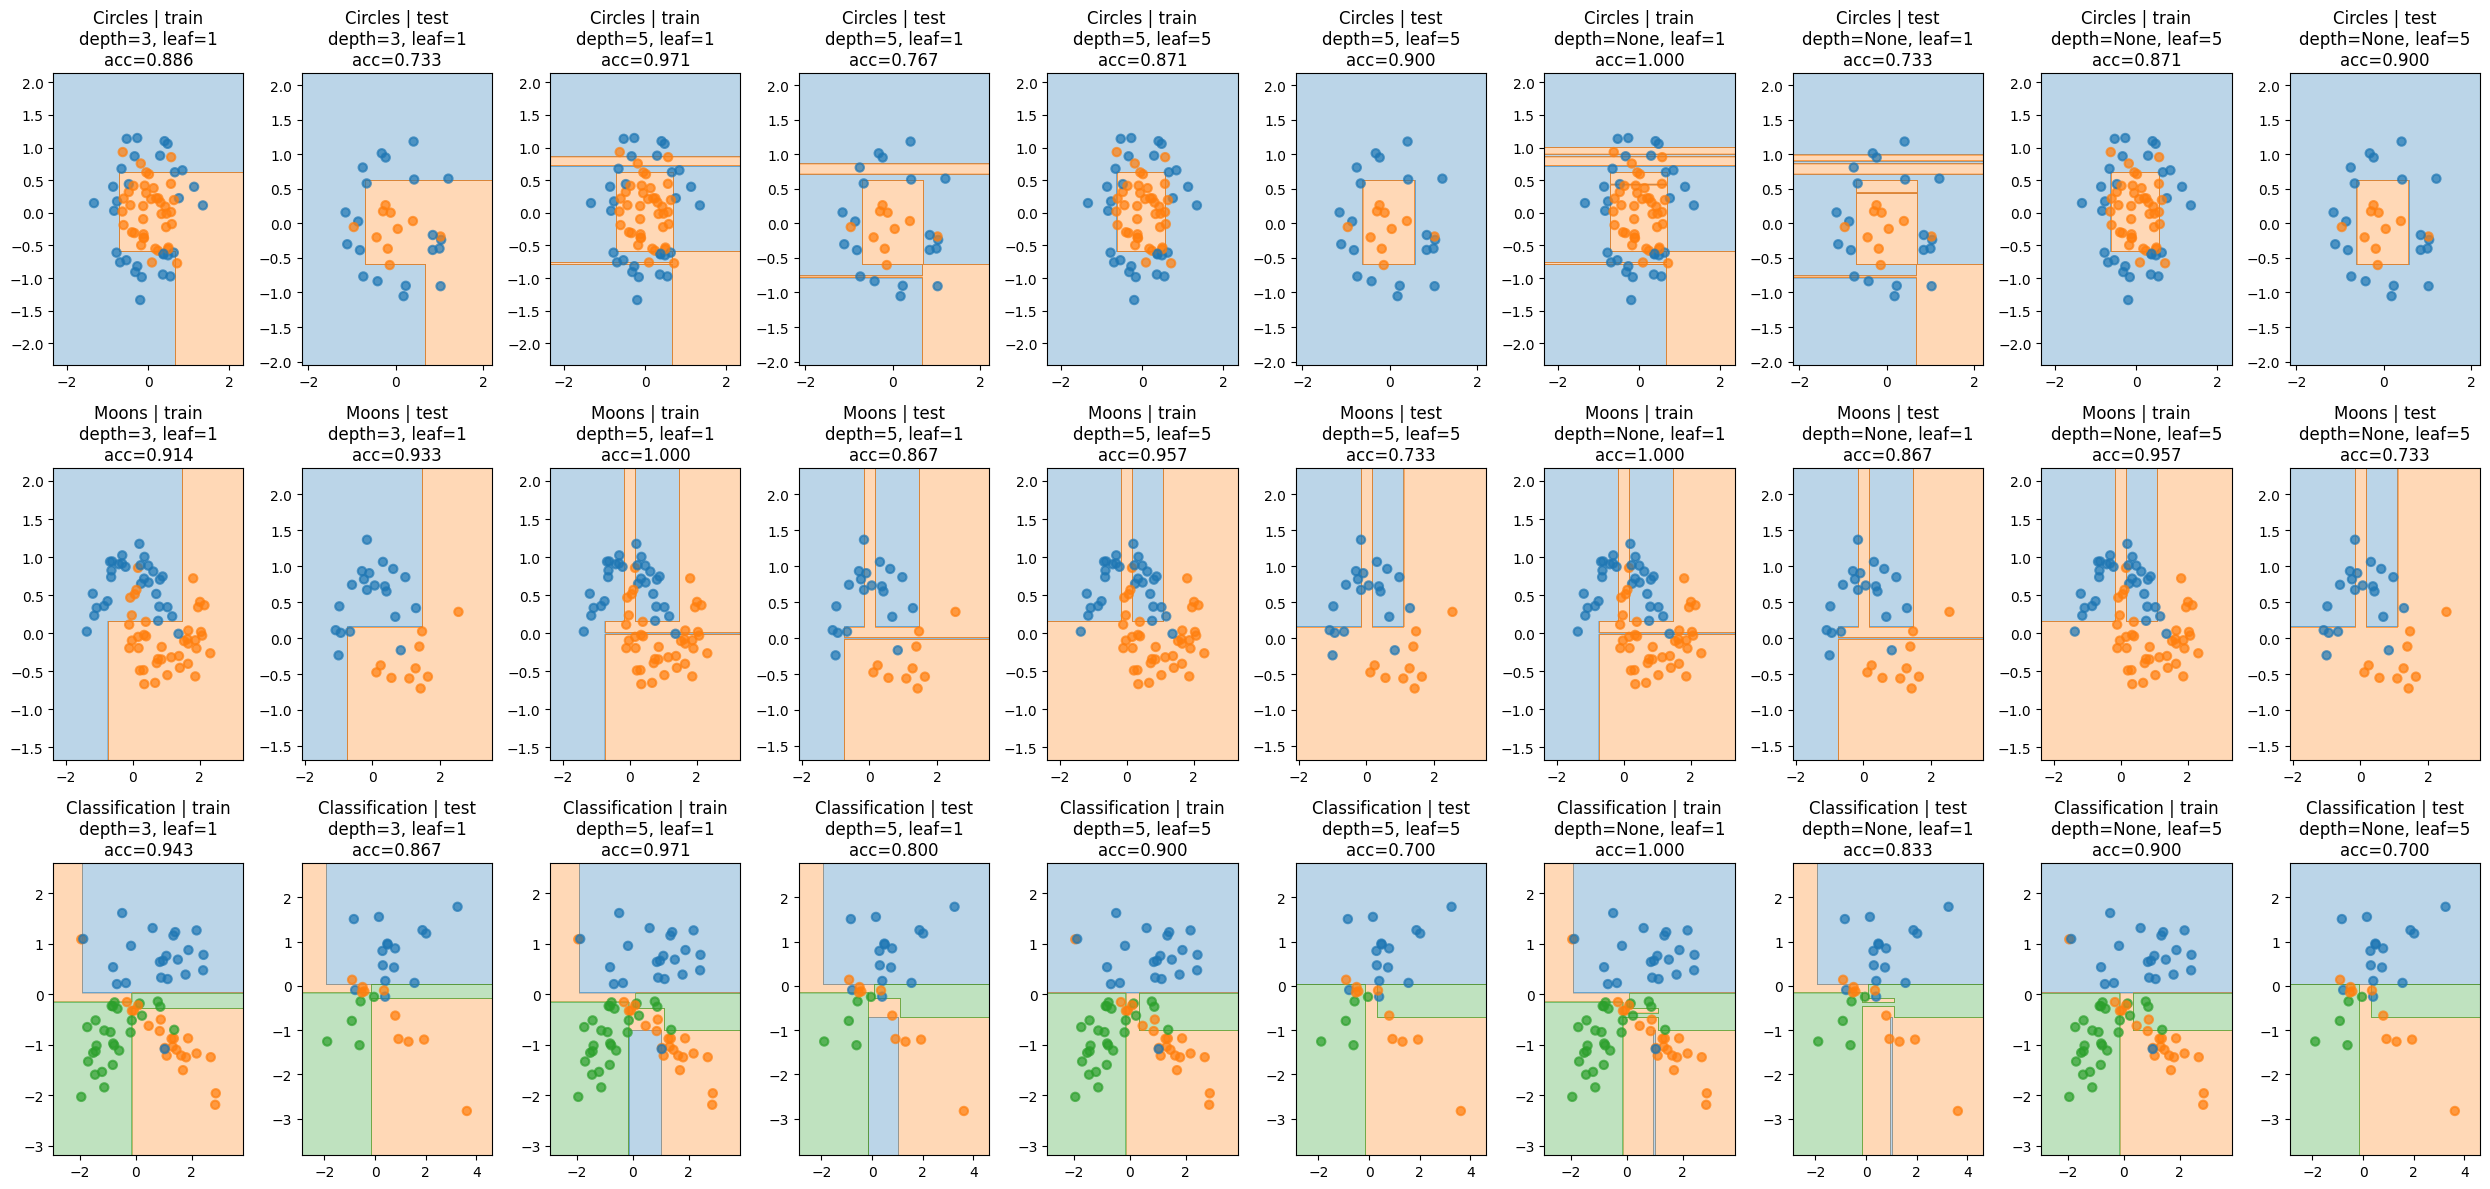

In [21]:
params = [
    {"max_depth": 3, "min_samples_leaf": 1},
    {"max_depth": 5, "min_samples_leaf": 1},
    {"max_depth": 5, "min_samples_leaf": 5},
    {"max_depth": None, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_leaf": 5},
]

results = []

plt.figure(figsize=(25, 12))

for i, (dataset_name, (X, y)) in enumerate(datasets.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    for j, param in enumerate(params):
        clf = DecisionTreeClassifier(random_state=42, **param)
        clf.fit(X_train, y_train)

        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)

        train_accuracy = accuracy_score(y_train, train_pred)
        test_accuracy = accuracy_score(y_test, test_pred)

        results.append({
            "dataset": dataset_name,
            "max_depth": param["max_depth"],
            "min_samples_leaf": param["min_samples_leaf"],
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
            "gap": train_accuracy - test_accuracy
        })

        ax = plt.subplot(len(datasets), len(params) * 2, 2 * (i * len(params) + j) + 1)
        plt.sca(ax)
        plot_surface(clf, X_train, y_train)
        plt.title(
            f"{dataset_name} | train\n"
            f"depth={param['max_depth']}, leaf={param['min_samples_leaf']}\n"
            f"acc={train_accuracy:.3f}"
        )

        ax = plt.subplot(len(datasets), len(params) * 2, 2 * (i * len(params) + j) + 2)
        plt.sca(ax)
        plot_surface(clf, X_test, y_test)
        plt.title(
            f"{dataset_name} | test\n"
            f"depth={param['max_depth']}, leaf={param['min_samples_leaf']}\n"
            f"acc={test_accuracy:.3f}"
        )

plt.tight_layout()
plt.show()

In [22]:
results_df.sort_values(["dataset", "test_accuracy"], ascending=[True, False])

,dataset,train_accuracy,test_accuracy,gap
0,Circles,1.0,0.733333,0.266667
2,Classification,1.0,0.833333,0.166667
1,Moons,1.0,0.866667,0.133333


## Выводы по влиянию гиперпараметров

Эксперимент показывает ожидаемый компромисс между гибкостью модели и её способностью к обобщению.

При небольшом `max_depth` дерево строит сравнительно простую разделяющую поверхность. Это снижает риск переобучения, но в ряде случаев приводит к недообучению: модель оказывается недостаточно гибкой, чтобы корректно описать более сложную геометрию классов.

Увеличение глубины дерева делает границу решений более детализированной. На обучающей выборке это почти всегда приводит к росту accuracy, однако одновременно возрастает риск переобучения: дерево начинает подстраиваться не только под закономерности, но и под шум в данных. Особенно явно это проявляется при `max_depth=None` и `min_samples_leaf=1`, когда train accuracy достигает максимума, а качество на тесте снижается.

Параметр `min_samples_leaf` действует как дополнительная регуляризация. При увеличении минимального числа объектов в листе граница решений становится более гладкой, а сама модель — менее чувствительной к отдельным наблюдениям. Это часто улучшает качество на тесте, если исходное дерево было слишком сложным, однако слишком сильное ограничение может привести к потере важных локальных закономерностей.

Эффект регуляризации различается для разных датасетов. На более простых структурах сглаживание границы решений улучшает обобщение, тогда как на данных со сложной нелинейной формой классов избыточное упрощение модели может ухудшать качество. Таким образом, оптимальные параметры дерева зависят от геометрии распределения объектов и уровня шума в данных.

На практике это означает, что подбор гиперпараметров дерева — это не просто техническая настройка, а способ контролировать баланс между интерпретируемостью, гибкостью и устойчивостью модели.

## Интерактивная визуализация влияния гиперпараметров

Для более наглядного анализа была построена интерактивная визуализация, позволяющая сравнить разделяющие поверхности дерева при разных значениях `max_depth` и `min_samples_leaf`. Такой формат помогает быстрее увидеть, как регуляризация изменяет форму границы решений и влияет на сложность модели.

In [23]:
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
import seaborn as sns

datasets = {
    "make_circles": make_circles(noise=0.2, factor=0.5, random_state=42),
    "make_moons": make_moons(noise=0.2, random_state=42),
    "make_classification": make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                                                class_sep=0.8, random_state=3, n_redundant=0)
}

depth_values = [3, 5, None]
leaf_values = [1, 5]

palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

def calculate_decision_surface(clf, X):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    return xx, yy, Z

def create_interactive_visualization(dataset_name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    fig = go.Figure()
    param_grid = [(d, l) for d in depth_values for l in leaf_values]

    for max_depth, min_samples_leaf in param_grid:
        clf = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        clf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        xx, yy, Z = calculate_decision_surface(clf, X)

        fig.add_trace(go.Contour(
            z=Z,
            x=xx[0],
            y=yy[:, 0],
            colorscale="Viridis",
            opacity=0.5,
            showscale=False,
            visible=False
        ))

        fig.add_trace(go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode="markers",
            marker=dict(
                color=y,
                colorscale="Viridis",
                line=dict(width=1)
            ),
            visible=False
        ))

    for i in range(2):
        fig.data[i].visible = True

    steps = []
    for i, (max_depth, min_samples_leaf) in enumerate(param_grid):
        clf = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        clf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        step = dict(
            method="update",
            args=[
                {"visible": [False] * len(fig.data)},
                {
                    "title": (
                        f"{dataset_name} | depth={max_depth}, leaf={min_samples_leaf} | "
                        f"train_acc={train_acc:.3f}, test_acc={test_acc:.3f}"
                    )
                }
            ]
        )
        step["args"][0]["visible"][2 * i] = True
        step["args"][0]["visible"][2 * i + 1] = True
        steps.append(step)

    fig.update_layout(
        sliders=[dict(
            active=0,
            currentvalue={"prefix": "Parameters: "},
            pad={"t": 50},
            steps=steps
        )],
        title=f"Interactive Decision Surface: {dataset_name}",
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        showlegend=False
    )

    return fig

for dataset_name, (X, y) in datasets.items():
    fig = create_interactive_visualization(dataset_name, X, y)
    fig.show()


# Реализация выбора разбиения и построения Decision Tree с нуля

На этом этапе реализуется ключевая логика решающего дерева для задачи бинарной классификации: выбор оптимального разбиения по критерию Джини и обработка как вещественных, так и категориальных признаков.

Цель блока — построить собственную реализацию дерева решений и проверить, насколько информативность признаков согласуется с визуальной структурой данных.

## Выбор оптимального порога по критерию Джини

Первый шаг в построении дерева — для каждого признака перебрать возможные пороги разбиения и выбрать тот, который даёт наилучшее уменьшение неоднородности классов. Для этого реализуется функция поиска оптимального split по критерию Джини.

In [24]:
def find_best_split(feature_vector, target_vector):
    """
    Поиск оптимального порога разбиения по критерию Джини
    для одномерного вещественного признака.

    Parameters
    ----------
    feature_vector : np.ndarray
        Значения признака.
    target_vector : np.ndarray
        Бинарные метки классов.

    Returns
    -------
    thresholds : np.ndarray
        Все кандидаты на порог.
    gini_scores : list
        Значения критерия Джини для каждого порога.
    threshold_best : float
        Лучший порог.
    gini_best : float
        Лучшее значение критерия.
    """
    sorted_indices = np.argsort(feature_vector)
    sorted_features = feature_vector[sorted_indices]
    sorted_targets = target_vector[sorted_indices].astype(int)

    unique_values = np.unique(sorted_features)
    if len(unique_values) == 1:
        return [], [], None, None

    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    gini_scores = []
    gini_best = None
    threshold_best = None

    for threshold in thresholds:
        left_mask = sorted_features < threshold
        right_mask = ~left_mask

        left_targets = sorted_targets[left_mask]
        right_targets = sorted_targets[right_mask]

        left_size = len(left_targets)
        right_size = len(right_targets)
        total_size = len(sorted_targets)

        if left_size == 0 or right_size == 0:
            continue

        left_probs = np.bincount(left_targets, minlength=2) / left_size
        right_probs = np.bincount(right_targets, minlength=2) / right_size

        left_gini = 1 - np.sum(left_probs ** 2)
        right_gini = 1 - np.sum(right_probs ** 2)

        gini = -(left_size / total_size) * left_gini - (right_size / total_size) * right_gini
        gini_scores.append(gini)

        if gini_best is None or gini > gini_best:
            gini_best = gini
            threshold_best = threshold

    return thresholds, gini_scores, threshold_best, gini_best

## Анализ информативности признаков на датасете students.csv

После реализации функции выбора разбиения полезно проверить её поведение на реальных данных. Для этого используется датасет `students.csv`, в котором первые пять столбцов являются признаками, а последний столбец — бинарной целевой переменной.

Для каждого признака строятся:
- кривая зависимости критерия Джини от порога разбиения;
- scatter-график «значение признака — класс».

Такой анализ позволяет понять, какой признак наиболее полезен для первого разбиения дерева.

In [25]:
data = pd.read_csv("students.csv")
print(data.shape)
display(data.head())
print("Columns:", list(data.columns))

(258, 6)


,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


Columns: ['STG', 'SCG', 'STR', 'LPR', 'PEG', 'UNS']


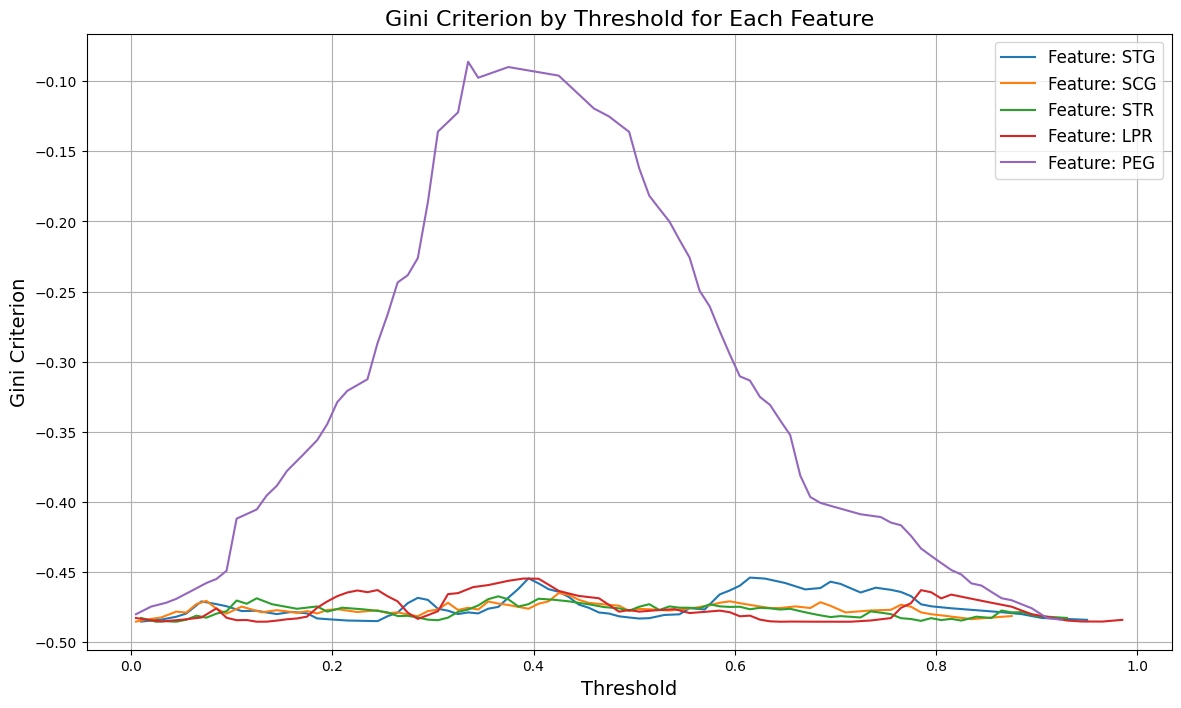

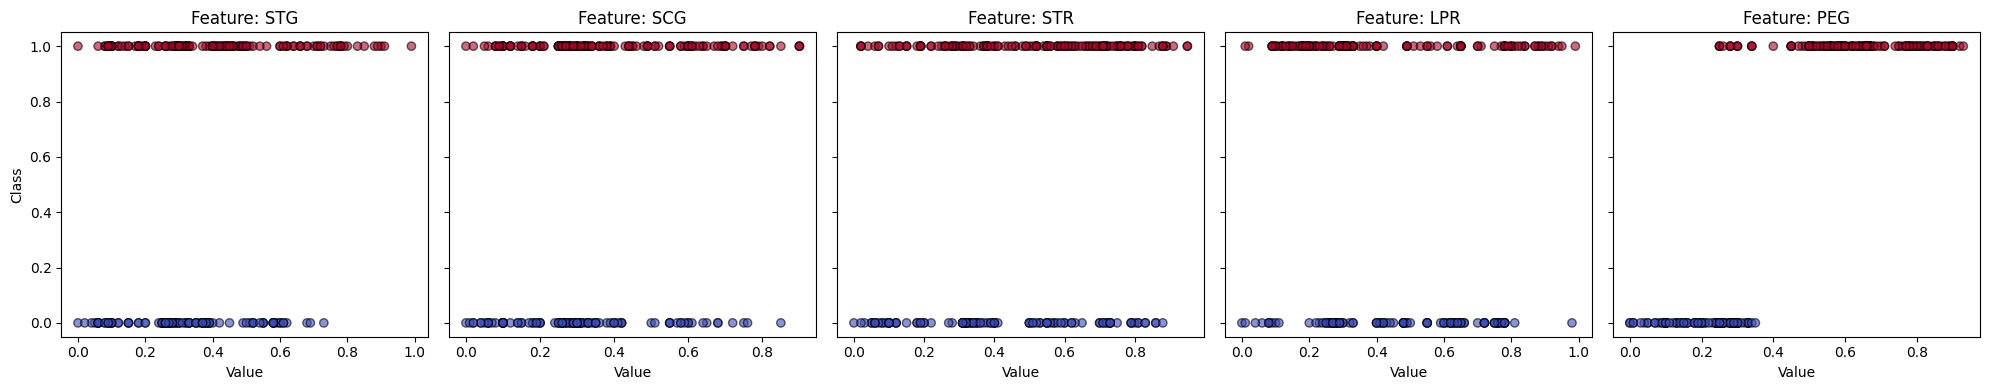

In [26]:
from typing import List, Tuple
def compute_gini_curves(data: pd.DataFrame, features: List[str], target: str) -> Tuple[List, List]:
    gini_curves = {}
    for feature in features:
        thresholds, ginis, _, _ = find_best_split(data[feature].values, data[target].values)
        gini_curves[feature] = (thresholds, ginis)
    return gini_curves

features = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
target = 'UNS'

gini_curves = compute_gini_curves(data, features, target)

plt.figure(figsize=(14, 8))
for feature, (thresholds, ginis) in gini_curves.items():
    plt.plot(thresholds, ginis, label=f'Feature: {feature}')
plt.title("Gini Criterion by Threshold for Each Feature", fontsize=16)
plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Gini Criterion", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data[target], alpha=0.6, c=data[target], cmap='coolwarm', edgecolor='k')
    axes[i].set_title(f"Feature: {feature}", fontsize=12)
    axes[i].set_xlabel("Value")
    if i == 0:
        axes[i].set_ylabel("Class")
plt.tight_layout()
plt.show()

## Интерпретация кривых критерия Джини

Построенные зависимости позволяют оценить, насколько хорошо каждый признак разделяет классы уже на первом шаге построения дерева. Далее анализируется, какой признак даёт наиболее сильное разбиение, насколько этот вывод согласуется с визуальной структурой данных и как выглядят кривые для сильных и слабых признаков.

## Выводы по информативности признаков

Среди всех признаков наилучший результат показывает **PEG**: именно для него значение критерия Джини достигает наименее отрицательных значений, а сама кривая заметно выделяется на фоне остальных. Это означает, что по признаку PEG можно выбрать порог, который значительно лучше разделяет объекты двух классов уже на первом шаге дерева.

Этот вывод согласуется и с визуальной оценкой scatter-графиков. Для PEG наблюдается наиболее выраженное разделение между классами, тогда как по остальным признакам точки двух классов перемешаны заметно сильнее.

Для хороших признаков кривая критерия Джини обычно имеет ярко выраженный максимум: это указывает на существование порога, при котором выборка делится на два относительно однородных подмножества. Напротив, для слабых признаков кривая остаётся почти плоской и не демонстрирует выраженного оптимума, что говорит о слабой способности такого признака разделять классы.

Таким образом, на данном датасете именно PEG выступает наиболее информативным кандидатом для первого разбиения дерева.

## Реализация собственного Decision Tree

После анализа критерия Джини следующим шагом была реализация дерева решений с нуля. В основе используется жадный алгоритм построения дерева: на каждом узле выбирается разбиение, максимизирующее качество разделения по критерию Джини, а рекурсия продолжается до выполнения условия остановки.

В реализации поддерживаются:
- вещественные и категориальные признаки,
- рекурсивное построение дерева,
- предсказание для новых объектов.

In [28]:
import numpy as np
from collections import Counter


class DecisionTree:
    """
    Decision Tree for binary classification with support for:
    - real-valued features
    - categorical features

    Splits are selected greedily using the Gini criterion.
    """

    def __init__(
        self,
        feature_types,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ):
        valid_types = {"real", "categorical"}
        if any(feature_type not in valid_types for feature_type in feature_types):
            raise ValueError("Unknown feature type detected")

        if min_samples_split < 2:
            raise ValueError("min_samples_split must be at least 2")
        if min_samples_leaf < 1:
            raise ValueError("min_samples_leaf must be at least 1")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _make_terminal_node(self, node, sub_y):
        node["type"] = "terminal"
        node["class"] = Counter(sub_y).most_common(1)[0][0]

    def _get_ordered_categorical_feature(self, feature_vector, target_vector):
        """
        Orders categories using target statistics:
        category_score = count(category) / (positive_count(category) + 1e-6)

        Returns:
            encoded_feature_vector: np.ndarray of ordered category ids
            categories_map: dict from category value to ordered integer
        """
        counts = Counter(feature_vector)
        positives = Counter(feature_vector[target_vector == 1])

        ratio = {}
        for category, total_count in counts.items():
            positive_count = positives.get(category, 0)
            ratio[category] = total_count / (positive_count + 1e-6)

        sorted_categories = [
            category for category, _ in sorted(ratio.items(), key=lambda x: x[1])
        ]
        categories_map = {
            category: idx for idx, category in enumerate(sorted_categories)
        }

        encoded_feature_vector = np.array(
            [categories_map[value] for value in feature_vector]
        )

        return encoded_feature_vector, categories_map

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        """
        Recursively builds the decision tree.
        """
        if (
            np.all(sub_y == sub_y[0]) or
            len(sub_y) < self._min_samples_split or
            (self._max_depth is not None and depth >= self._max_depth)
        ):
            self._make_terminal_node(node, sub_y)
            return

        feature_best = None
        threshold_best = None
        gini_best = None
        split_best = None
        categories_split_best = None

        n_features = sub_X.shape[1]

        for feature_idx in range(n_features):
            feature_type = self._feature_types[feature_idx]

            if feature_type == "real":
                feature_vector = sub_X[:, feature_idx]
                categories_map = None

            elif feature_type == "categorical":
                feature_vector, categories_map = self._get_ordered_categorical_feature(
                    sub_X[:, feature_idx],
                    sub_y
                )
            else:
                raise ValueError("Unsupported feature type")

            thresholds, ginis, threshold, gini = find_best_split(feature_vector, sub_y)

            if threshold is None:
                continue

            split = feature_vector < threshold

            if np.sum(split) < self._min_samples_leaf or np.sum(~split) < self._min_samples_leaf:
                continue

            if gini_best is None or gini > gini_best:
                feature_best = feature_idx
                threshold_best = threshold
                gini_best = gini
                split_best = split

                if feature_type == "real":
                    categories_split_best = None
                else:
                    categories_split_best = {
                        category
                        for category, mapped_value in categories_map.items()
                        if mapped_value < threshold
                    }

        if feature_best is None:
            self._make_terminal_node(node, sub_y)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = categories_split_best

        node["left_child"] = {}
        node["right_child"] = {}

        self._fit_node(
            sub_X[split_best],
            sub_y[split_best],
            node["left_child"],
            depth + 1
        )
        self._fit_node(
            sub_X[~split_best],
            sub_y[~split_best],
            node["right_child"],
            depth + 1
        )

    def _predict_node(self, x, node):
        """
        Recursively predicts class for a single object.
        """
        if node["type"] == "terminal":
            return node["class"]

        feature_idx = node["feature_split"]
        feature_type = self._feature_types[feature_idx]

        if feature_type == "real":
            if x[feature_idx] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            return self._predict_node(x, node["right_child"])

        elif feature_type == "categorical":
            if x[feature_idx] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            return self._predict_node(x, node["right_child"])

        else:
            raise ValueError("Unsupported feature type")

    def fit(self, X, y):
        """
        Fits the decision tree.
        """
        X = np.asarray(X)
        y = np.asarray(y).astype(int)

        self._tree = {}
        self._fit_node(X, y, self._tree, depth=0)
        return self

    def predict(self, X):
        """
        Predicts classes for input objects.
        """
        X = np.asarray(X)
        return np.array([self._predict_node(x, self._tree) for x in X])

## Проверка реализации на категориальном датасете [Mushroom](https://archive.ics.uci.edu/ml/datasets/Mushroom)

Чтобы проверить корректность работы дерева на категориальных признаках, модель была протестирована на датасете Mushroom. Все признаки в нём категориальные, поэтому это хороший тест для проверки логики обработки категорий и качества построенного дерева.

После кодирования категориальных значений модель обучается на половине выборки и оценивается по accuracy на оставшейся части.

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mushrooms = pd.read_csv("agaricus-lepiota.data", header=None)
print("Dataset shape:", mushrooms.shape)

X = mushrooms.iloc[:, 1:].copy()
y = mushrooms.iloc[:, 0].replace({"e": 0, "p": 1}).to_numpy()

X = X.apply(LabelEncoder().fit_transform).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

tree = DecisionTree(feature_types=["categorical"] * X_train.shape[1])
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {acc:.4f}")

Dataset shape: (8124, 23)


/tmp/ipykernel_4923/2797170003.py:9: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Test accuracy: 1.0000


Полученное значение accuracy близко к 1, что подтверждает корректность реализации дерева для категориальных признаков. Кроме того, такой результат согласуется с известной структурой датасета Mushroom, который хорошо разделяется по комбинациям признаков.

## Анализ влияния гиперпараметров на качество модели

После базовой проверки реализации следующим шагом является исследование того, как ограничения на сложность дерева влияют на качество предсказания. Для этого рассматриваются параметры:
- `max_depth`,
- `min_samples_split`,
- `min_samples_leaf`.

Эксперимент проводится на датасете tic-tac-toe, а качество оценивается по accuracy на тестовой выборке.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

class DecisionTree:
    def __init__(self, feature_types, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        if len(sub_y) <= 1 or (self._max_depth is not None and depth >= self._max_depth):
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None

        for feature in range(sub_X.shape[1]):
            feature_vector = sub_X[:, feature]
            thresholds = np.unique(feature_vector)

            for threshold in thresholds:
                left_mask = feature_vector < threshold
                right_mask = ~left_mask

                if np.sum(left_mask) < self._min_samples_leaf or np.sum(right_mask) < self._min_samples_leaf:
                    continue

                left_counts = Counter(sub_y[left_mask])
                right_counts = Counter(sub_y[right_mask])

                left_gini = 1.0 - sum((left_counts[class_] / np.sum(left_mask)) ** 2 for class_ in left_counts)
                right_gini = 1.0 - sum((right_counts[class_] / np.sum(right_mask)) ** 2 for class_ in right_counts)

                gini = (np.sum(left_mask) * left_gini + np.sum(right_mask) * right_gini) / len(sub_y)

                if gini_best is None or gini < gini_best:
                    feature_best = feature
                    threshold_best = threshold
                    gini_best = gini
                    split = left_mask

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        node["threshold"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[~split], sub_y[~split], node["right_child"], depth + 1)

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        if x[node["feature_split"]] < node["threshold"]:
            return self._predict_node(x, node["left_child"])
        else:
            return self._predict_node(x, node["right_child"])

    def fit(self, X, y):
        y = y.astype(int)
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        return np.array([self._predict_node(x, self._tree) for x in X])

data = pd.read_csv(
    "https://raw.githubusercontent.com/esokolov/ml-course-hse/master/2024-fall/homework-practice/homework-practice-05-trees/tic-tac-toe-endgame.csv"
)

data.columns = [f"feature_{i}" for i in range(9)] + ["target"]
data = data.replace({"x": 1, "o": -1, "b": 0, "positive": 1, "negative": 0})

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

max_depths = [1, 3, 5, 10]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 5, 10]

results = []

for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        for min_samples_leaf in min_samples_leafs:
            tree = DecisionTree(
                feature_types=["categorical"] * 9,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf
            )
            tree.fit(X_train, y_train)
            y_pred = tree.predict(X_test)

            results.append({
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "accuracy": accuracy_score(y_test, y_pred)
            })

results_df = pd.DataFrame(results)
results_df.head()


/tmp/ipykernel_4923/997972166.py:88: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,max_depth,min_samples_split,min_samples_leaf,accuracy
0,1,2,1,0.6875
1,1,2,5,0.6875
2,1,2,10,0.6875
3,1,5,1,0.6875
4,1,5,5,0.6875


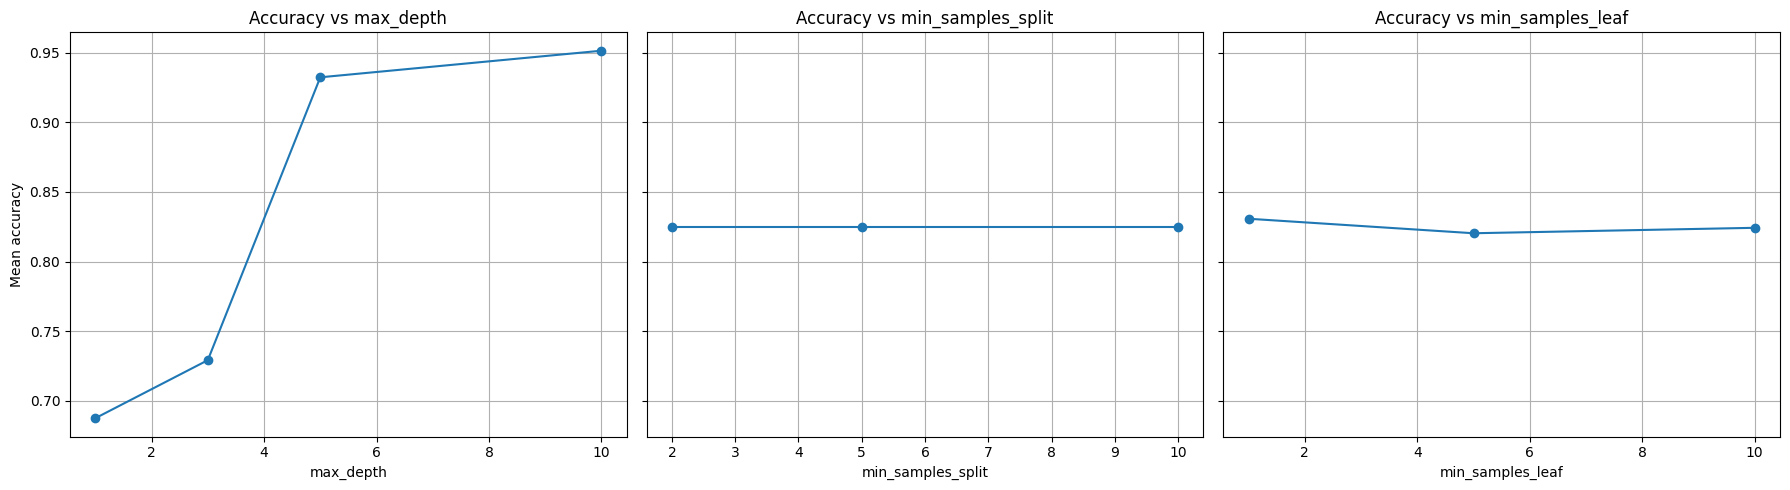

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

mean_by_depth = results_df.groupby("max_depth")["accuracy"].mean()
axes[0].plot(mean_by_depth.index, mean_by_depth.values, marker="o")
axes[0].set_title("Accuracy vs max_depth")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Mean accuracy")
axes[0].grid(True)

mean_by_split = results_df.groupby("min_samples_split")["accuracy"].mean()
axes[1].plot(mean_by_split.index, mean_by_split.values, marker="o")
axes[1].set_title("Accuracy vs min_samples_split")
axes[1].set_xlabel("min_samples_split")
axes[1].grid(True)

mean_by_leaf = results_df.groupby("min_samples_leaf")["accuracy"].mean()
axes[2].plot(mean_by_leaf.index, mean_by_leaf.values, marker="o")
axes[2].set_title("Accuracy vs min_samples_leaf")
axes[2].set_xlabel("min_samples_leaf")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Выводы по гиперпараметрам

Эксперимент показывает, что ограничение глубины дерева и минимального числа объектов в узле позволяет контролировать сложность модели и влияет на её способность к обобщению. При слишком слабой регуляризации дерево становится избыточно гибким, тогда как слишком жёсткие ограничения могут приводить к недообучению.

Таким образом, даже для собственной реализации дерева настройка гиперпараметров играет критическую роль в достижении хорошего качества на новых данных.

## Linear Regression Tree

Следующий шаг — обобщить идею дерева решений на задачу регрессии. В этой реализации в листьях находятся не константные предсказания, а линейные модели.

Порог разбиения выбирается не по дисперсии целевой переменной, а по суммарной ошибке линейных моделей, обученных в левом и правом поддеревьях. Такой подход позволяет строить более гибкую piecewise-linear модель.

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


class LinearRegressionTree:
    """
    Дерево для задачи регрессии, в листьях которого находятся
    линейные модели, а разбиение выбирается по минимизации MSE
    линейных моделей после split.
    """

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        n_quantiles=10
    ):
        if min_samples_split < 2:
            raise ValueError("min_samples_split должен быть >= 2")
        if min_samples_leaf < 1:
            raise ValueError("min_samples_leaf должен быть >= 1")
        if n_quantiles < 1:
            raise ValueError("n_quantiles должен быть >= 1")

        self._tree = {}
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.n_quantiles = n_quantiles

    def _make_terminal_node(self, node, sub_X, sub_y):
        """
        Создаёт терминальный узел и обучает в нём линейную регрессию.
        """
        node["type"] = "terminal"
        model = LinearRegression()
        model.fit(sub_X, sub_y)
        node["model"] = model

    def _get_thresholds(self, feature_vector):
        """
        Выбирает кандидаты на пороги как квантили признака.
        """
        thresholds = np.quantile(
            feature_vector,
            np.linspace(0, 1, self.n_quantiles + 2)[1:-1]
        )
        thresholds = np.unique(thresholds)
        return thresholds

    def _fit_node(self, sub_X, sub_y, node, depth=0):
        """
        Рекурсивно строит дерево.
        """

        # Критерии остановки
        if (
            len(sub_y) < self._min_samples_split or
            (self._max_depth is not None and depth >= self._max_depth)
        ):
            self._make_terminal_node(node, sub_X, sub_y)
            return

        feature_best = None
        threshold_best = None
        loss_best = None
        split_best = None

        n_features = sub_X.shape[1]

        for feature_idx in range(n_features):
            feature_vector = sub_X[:, feature_idx]
            thresholds = self._get_thresholds(feature_vector)

            if len(thresholds) == 0:
                continue

            for threshold in thresholds:
                left_mask = feature_vector < threshold
                right_mask = ~left_mask

                # Проверка минимального размера листа
                if (
                    np.sum(left_mask) < self._min_samples_leaf or
                    np.sum(right_mask) < self._min_samples_leaf
                ):
                    continue

                X_left, y_left = sub_X[left_mask], sub_y[left_mask]
                X_right, y_right = sub_X[right_mask], sub_y[right_mask]

                left_model = LinearRegression()
                right_model = LinearRegression()

                left_model.fit(X_left, y_left)
                right_model.fit(X_right, y_right)

                left_pred = left_model.predict(X_left)
                right_pred = right_model.predict(X_right)

                left_loss = mean_squared_error(y_left, left_pred)
                right_loss = mean_squared_error(y_right, right_pred)

                total_loss = (
                    (len(y_left) / len(sub_y)) * left_loss +
                    (len(y_right) / len(sub_y)) * right_loss
                )

                if loss_best is None or total_loss < loss_best:
                    feature_best = feature_idx
                    threshold_best = threshold
                    loss_best = total_loss
                    split_best = left_mask

        # Если хорошего разбиения не найдено — создаём лист
        if feature_best is None:
            self._make_terminal_node(node, sub_X, sub_y)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        node["threshold"] = threshold_best
        node["left_child"] = {}
        node["right_child"] = {}

        self._fit_node(
            sub_X[split_best],
            sub_y[split_best],
            node["left_child"],
            depth + 1
        )
        self._fit_node(
            sub_X[~split_best],
            sub_y[~split_best],
            node["right_child"],
            depth + 1
        )

    def _predict_node(self, x, node):
        """
        Рекурсивное предсказание для одного объекта.
        """
        if node["type"] == "terminal":
            return node["model"].predict([x])[0]

        if x[node["feature_split"]] < node["threshold"]:
            return self._predict_node(x, node["left_child"])
        return self._predict_node(x, node["right_child"])

    def fit(self, X, y):
        """
        Обучение дерева.
        """
        X = np.asarray(X)
        y = np.asarray(y, dtype=float)

        self._tree = {}
        self._fit_node(X, y, self._tree, depth=0)
        return self

    def predict(self, X):
        """
        Предсказание для набора объектов.
        """
        X = np.asarray(X)
        return np.array([self._predict_node(x, self._tree) for x in X])

,Metric,Value
0,MSE,2.134561
1,MAE,1.156435
2,R2,0.903178


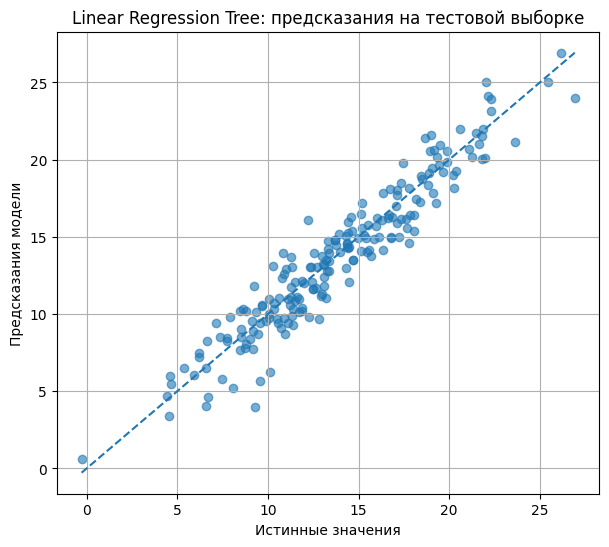

In [33]:
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Генерация нелинейного регрессионного датасета
X, y = make_friedman1(n_samples=1000, n_features=10, noise=1.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучение модели
lr_tree = LinearRegressionTree(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    n_quantiles=10
)

lr_tree.fit(X_train, y_train)
y_pred = lr_tree.predict(X_test)

# Метрики
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results_df = pd.DataFrame({
    "Metric": ["MSE", "MAE", "R2"],
    "Value": [mse, mae, r2]
})
display(results_df)

# Визуализация
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказания модели")
plt.title("Linear Regression Tree: предсказания на тестовой выборке")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.grid(True)
plt.show()

# сравнение с baseline-моделями

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=42),
    "Linear Regression Tree": LinearRegressionTree(
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=10,
        n_quantiles=10
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("MSE")
display(results_df)

,Model,MSE,MAE,R2
2,Linear Regression Tree,2.134561,1.156435,0.903178
0,Linear Regression,5.252155,1.867863,0.761767
1,Decision Tree,7.905655,2.275222,0.641407


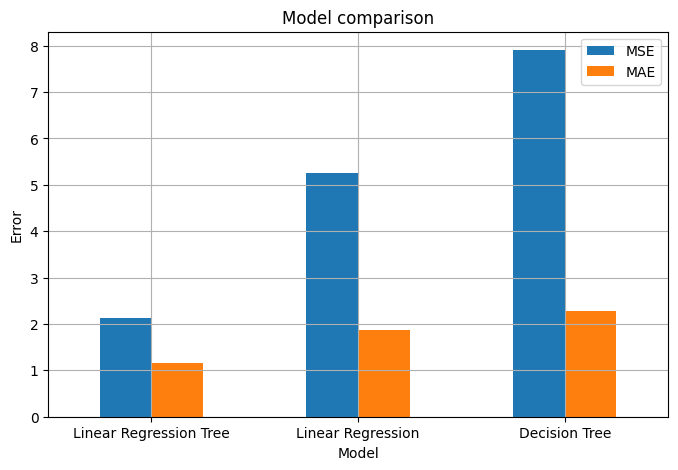

In [35]:
results_df.set_index("Model")[["MSE", "MAE"]].plot(kind="bar", figsize=(8,5))
plt.title("Model comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

## Сравнение моделей

Сравнение с базовыми моделями показывает, что Linear Regression Tree позволяет лучше учитывать нелинейную структуру данных по сравнению с линейной регрессией, сохраняя при этом более гладкое поведение по сравнению с классическим деревом решений.

В отличие от стандартного Decision Tree, который строит кусочно-постоянную функцию, предложенная модель формирует кусочно-линейную аппроксимацию, что улучшает качество на задачах с гладкой зависимостью.

Таким образом, Linear Regression Tree сочетает интерпретируемость дерева с гибкостью линейных моделей.